In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
property = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Hero vLearn\\Graded Assignments\\Graded Assignment on Statistics for Decision Making\\property.csv")
property.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
# Q1:
# For the suburb of Altona, it is postulated that a typical property sells for $800,000.
# Use the data at hand to test this assumption. Is the typical property price really $800,000 or has it increased? Use a significance level of 5%. 


#Solution:

# Step 1: Filtering data for the suburb 'Altona'
altona = property[property['Suburb'] == 'Altona']

# Step 2: Descriptive statistics
mean_price = altona['Price'].mean()
std_price = altona['Price'].std()
n = altona['Price'].count()

print(f"Sample size (n): {n}")
print(f"Mean price: {mean_price:.2f}")
print(f"Standard Deviation: {std_price:.2f}")

# Step 3: Hypothesis Test statement for Property Price of 'Altona' Suburb is 80000 or >80000
# Null Hypothesis H0: μ = 800000
# Alternative Hypothesis H1: μ > 800000

t_stat, p_value = stats.ttest_1samp(altona['Price'], 800000)

# Since it's a one-tailed test (μ > 800000), divide p-value by 2
p_value_one_tailed = p_value / 2

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value (one-tailed): {p_value_one_tailed:.5f}")

# Step 4: Decision
alpha = 0.05 # For Significance Level is 5%
if (t_stat > 0) and (p_value_one_tailed < alpha):
    print("Reject the null hypothesis: The average price in Altona is significantly greater than $800,000.")
else:
    print("Fail to reject the null hypothesis: Insufficient evidence that prices are higher than $800,000.")

Sample size (n): 74
Mean price: 834830.41
Standard Deviation: 291546.05
T-statistic: 1.028
P-value (one-tailed): 0.15374
Fail to reject the null hypothesis: Insufficient evidence that prices are higher than $800,000.


#### <u>Interpretation for Output of Q1:</u>

The hypothesis test for the suburb **Altona** indicated:

- Sample mean price = $834,830.41
- t-statistic = 1.028, one-tailed p-value = 0.1537

Since the p-value (0.1537) is greater than the 5% significance level, we **fail to reject the null hypothesis**.  
Hence, there is **insufficient evidence** to conclude that the average property price in Altona has increased beyond $800,000.


Winter sample size: 2300
Summer sample size: 4036

Mean Winter Price: 1116647.59
Mean Summer Price: 1048054.73

T-statistic: 3.921
P-value (two-tailed): 0.00009
Reject the null hypothesis.


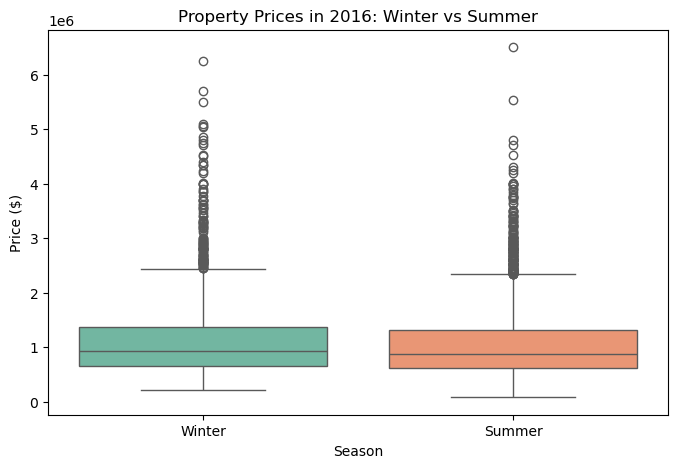

In [ ]:
# Q2:
# For the year 2016, is there any difference in the prices of properties sold in the summer months vs winter months?
# Consider months from October till March as winter months and rest as summer months. Use a significance level of 5%. 

# Solution:

# Step 1: First, creating a copy and convert 'Date' column to datetime format
property['Date'] = pd.to_datetime(property['Date'], dayfirst=True, errors='coerce')

# Step 2: Filtering data for the year 2016
property_2016 = property[property['Date'].dt.year == 2016]

# Step 3: Drop missing prices
property_2016 = property_2016.dropna(subset=['Price'])

# Step 4: Extracting month number
property_2016['Month'] = property_2016['Date'].dt.month

# Step 5: Categorizing months into Winter (Oct–Mar) and Summer (Apr–Sep)
def season_label(month):
    if month in [10, 11, 12, 1, 2, 3]:
        return 'Winter'
    else:
        return 'Summer'

property_2016['Season'] = property_2016['Month'].apply(season_label)

# Step 6: Splitting the dataset to:
winter_prices = property_2016[property_2016['Season'] == 'Winter']['Price']
summer_prices = property_2016[property_2016['Season'] == 'Summer']['Price']

print(f"Winter sample size: {len(winter_prices)}")
print(f"Summer sample size: {len(summer_prices)}")

# Step 7: Descriptive statistics
print("\nMean Winter Price:", round(winter_prices.mean(), 2))
print("Mean Summer Price:", round(summer_prices.mean(), 2))

# Step 8: Hypothesis Testing Statement
# H0: μ_winter = μ_summer (The average property price in winter months is equal to the average price in summer months.)
# H1: μ_winter ≠ μ_summer (The average property price in winter months is not equal to the average price in summer months.)

t_stat, p_value = stats.ttest_ind(winter_prices, summer_prices, equal_var=False)  # t-test condtion

print(f"\nT-statistic: {t_stat:.3f}")
print(f"P-value (two-tailed): {p_value:.5f}")

# Step 9: Decision
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

# Visualization of Property Prices in 'Winter' and 'Summer' seasons of year 2016-
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='Price', hue='Season', data=property_2016, palette='Set2', legend=False)
plt.title('Property Prices in 2016: Winter vs Summer')
plt.ylabel('Price ($)')
plt.xlabel('Season')
plt.show()


#### <u>Interpretation of Output of Q2:</u>

For the year **2016**:
- Properties sold during **winter months (Oct–Mar)** had an average price of $1,116,647.59
- Properties sold during **summer months (Apr–Sep)** had an average price of $1,048,054.73
- Independent-samples t-test results:
  - t-statistic = 3.921
  - Two-tailed p-value = 0.00009

Since the p-value is **much below the 5% significance level**, we **reject the null hypothesis**.  
Hence, there is a **significant difference in property prices** between winter and summer months in 2016.

In [ ]:
# Q3:
# For the suburb of Abbotsford, what is the probability that out of 10 properties sold, 3 will not have a car parking space? Use the column car in the dataset. 
# Round off your answer to 3 decimal places.

# Solution:

from scipy.stats import binom

# Step 1: Filtering data for 'Abbotsford' Suburb
abbotsford = property[property['Suburb'] == 'Abbotsford']

# Step 2: Dropping missing 'Car' values
abbotsford = abbotsford.dropna(subset=['Car'])

# Step 3: Estimating probability (p) of not having a car space
p_no_car = np.mean(abbotsford['Car'] == 0)
print(f"Estimated probability (p) of no car parking: {p_no_car:.3f}")

# Step 4: Given n = 10 properties, x = 3 sold properties
n = 10
x = 3

# Step 5: Computing Binomial Probability
probability = binom.pmf(x, n, p_no_car)
print(f"Probability that exactly 3 out of 10 properties have no car parking: {probability:.3f}")

Estimated probability (p) of no car parking: 0.268
Probability that exactly 3 out of 10 properties have no car parking: 0.260


#### <u>Interpretation of Output of Q3:</u>
As output shows, there are roughly 26% chances that, out of 10 randomly selected Abbotsford properties, exactly 3 will not include a car parking space.

In [29]:
# Q4: In the suburb of Abbotsford, what are the chances of finding a property with 3 rooms? Round your answer to 3 decimal places.

# Solution:

# Step 1: Filtering data for Abbotsford
abbotsford = property[property['Suburb'] == 'Abbotsford']

# Step 2: Dropping missing 'Rooms' values (if any)
abbotsford = abbotsford.dropna(subset=['Rooms'])

# Step 3: Calculating probability of having 3 rooms
p_3rooms = np.mean(abbotsford['Rooms'] == 3)

# Step 4: Rounding to 3 decimal places
p_3rooms = round(p_3rooms, 3)

print(f"Probability that a property in Abbotsford has 3 rooms: {p_3rooms}")

Probability that a property in Abbotsford has 3 rooms: 0.357


#### <u>Interpretation of Output of Q4:</u>
In the suburb Abbotsford, the probability of selecting a property with 3 rooms is approximately 0.357. This indicates that about 35.7% of properties in Abbotsford have 3 rooms.

In [30]:
# Q5:
# In the suburb of Abbotsford, what are the chances of finding a property with 2 bathrooms? Round your answer to 3 decimal places.

#Solution:

# Step 1: Filtering data for Abbotsford
abbotsford = property[property['Suburb'] == 'Abbotsford']

# Step 2: Dropping missing 'Bathroom' values (if any)
abbotsford = abbotsford.dropna(subset=['Bathroom'])

# Step 3: Calculating probability of having 2 bathrooms
p_2bathrooms = np.mean(abbotsford['Bathroom'] == 2)

# Step 4: Rounding to 3 decimal places
p_2bathrooms = round(p_2bathrooms, 3)

print(f"Probability that a property in Abbotsford has 2 bathrooms: {p_2bathrooms}")

Probability that a property in Abbotsford has 2 bathrooms: 0.339


#### <u>Interpretation of Output of Q5:</u>
In the suburb Abbotsford, the probability of selecting a property with 2 bathrooms is approximately 0.339. This indicates that around 33.9% of properties have 2 bathrooms.